### Load The Dataset

In [1]:
import pandas as pd
data = pd.read_csv("Student_Scores.csv")
print(data.head(10))

     name  hours  score gender grades class
0   Aarav     10     76      M      A    9A
1    Riya      5     45      F      A    9B
2   Kabir     10     42      M      A   10A
3    Sana      4     55      F      C    9A
4  Vivaan      7     65      M      B   10B
5  Ishita      6     64      F      B    9C
6   Rohan      3     48      M      D    9B
7   Meera      9     90      F      A   11A
8  Aditya      2     38      M      F    9C
9   Kavya     11     93      F      A   12A


### Inspect the dataset

In [2]:
print('Columns: ',data.columns.tolist())
print('\nDataset Info: ')
print(data.info())

print('\nDataset Completeness: ')
print(data.isnull().sum())

print('\nDataset Consistency: ')
print(data.dtypes)

Columns:  ['name', 'hours', 'score', 'gender', 'grades', 'class']

Dataset Info: 
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 92 entries, 0 to 91
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   name    92 non-null     object
 1   hours   92 non-null     int64 
 2   score   92 non-null     int64 
 3   gender  92 non-null     object
 4   grades  92 non-null     object
 5   class   92 non-null     object
dtypes: int64(2), object(4)
memory usage: 4.4+ KB
None

Dataset Completeness: 
name      0
hours     0
score     0
gender    0
grades    0
class     0
dtype: int64

Dataset Consistency: 
name      object
hours      int64
score      int64
gender    object
grades    object
class     object
dtype: object


In [3]:
print('\nDataset Describe:')
print(data.describe())
print('\nDataset Time-Keeping:')
print('\nNo timestamps')

print('\nDataset Bias:')
print(data['gender'].value_counts(normalize=True))
print(data['grades'].value_counts(normalize=True))
data['class'].value_counts(normalize=True)



Dataset Describe:
           hours      score
count  92.000000  92.000000
mean    6.532609  68.076087
std     2.289254  15.978855
min     2.000000  35.000000
25%     5.000000  55.750000
50%     7.000000  68.500000
75%     8.000000  81.250000
max    11.000000  94.000000

Dataset Time-Keeping:

No timestamps

Dataset Bias:
gender
F    0.51087
M    0.48913
Name: proportion, dtype: float64
grades
B    0.347826
A    0.336957
C    0.195652
D    0.086957
F    0.032609
Name: proportion, dtype: float64


class
9A     0.141304
10A    0.119565
9B     0.108696
9C     0.108696
10B    0.086957
11A    0.086957
10C    0.076087
12A    0.065217
12B    0.065217
11B    0.054348
12C    0.054348
11C    0.032609
Name: proportion, dtype: float64

### Separate Features and Label

In [4]:
catagorical= data.select_dtypes(include='object').columns
numerical=data.select_dtypes(include=['int64','float64']).columns

print("Categorial Featuers:",list(catagorical))
print("Numerical Features:",list(numerical))

x=data[["hours"]]
y= data["score"]

Categorial Featuers: ['name', 'gender', 'grades', 'class']
Numerical Features: ['hours', 'score']


### Data Distribution

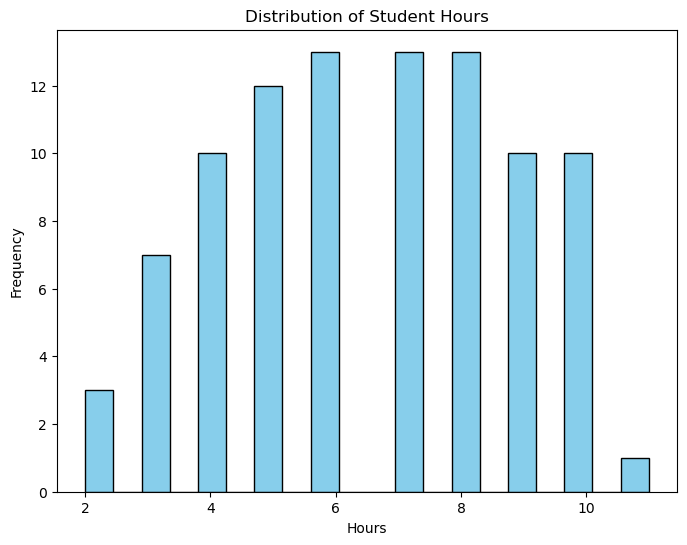

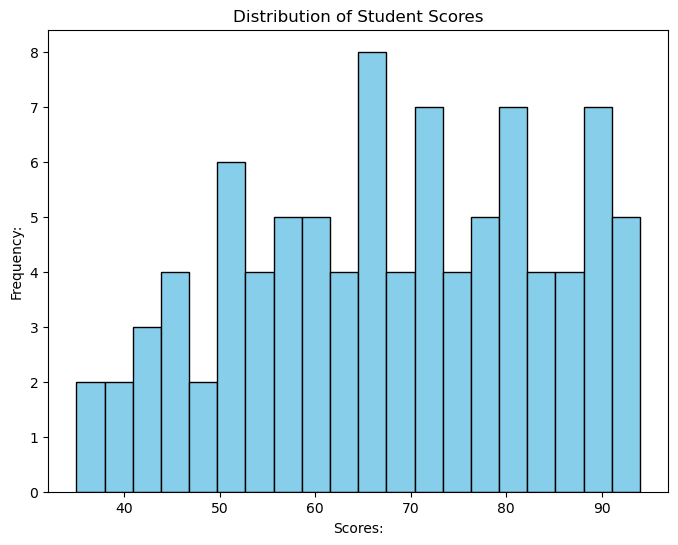

In [5]:
import matplotlib.pyplot as plt
plt.figure(figsize=(8,6))
plt.hist(x,bins=20,color='skyblue',edgecolor='black')
plt.xlabel('Hours')
plt.ylabel('Frequency')
plt.title('Distribution of Student Hours')
plt.show()

plt.figure(figsize=(8,6))
plt.hist(y, bins=20,color='skyblue', edgecolor='black')
plt.xlabel('Scores:')
plt.ylabel('Frequency:')
plt.title('Distribution of Student Scores')
plt.show()

### Split the Data

In [6]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test= train_test_split(
    x,
    y,
    test_size=0.2,
    random_state=42
)


### Train The Model

In [7]:
from sklearn.linear_model import LinearRegression
model = LinearRegression()
model.fit(x_train,y_train)

print("Model Coefficient (Slope):",model.coef_[0])
print("Model Intercept:",model.intercept_)

Model Coefficient (Slope): 6.447227663100798
Model Intercept: 26.10799306915775


### Make Predictions

In [9]:
y_pred=model.predict(x_test)
pred_data={'Y_prediction': y_pred.round(2),'Y_test':y_test.reset_index(drop=True)}
prediction_table=pd.DataFrame(pred_data)
user_input=pd.DataFrame([[10]],columns=['hours'])
print(model.predict(user_input))

[90.5802697]


### Plot The Line of Regression

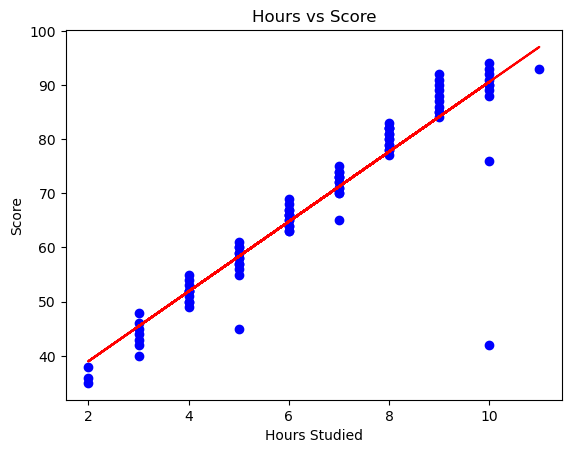

In [17]:
import matplotlib.pyplot as plt
plt.scatter(x,y,color='blue')
plt.plot(x,model.predict(x), color='red')
plt.title("Hours vs Score")
plt.xlabel("Hours Studied")
plt.ylabel("Score")
plt.show()

### Linear Regression Assumptions

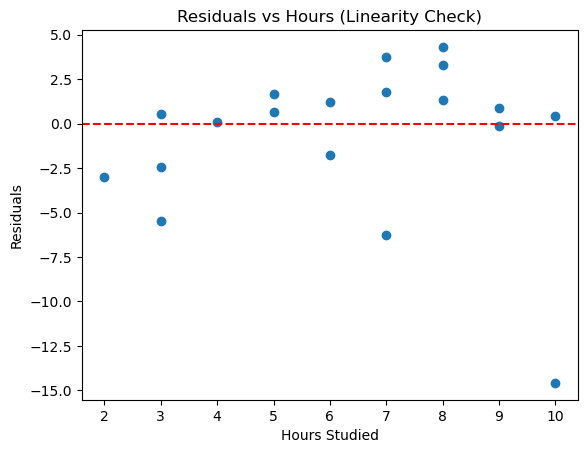

In [14]:
residuals=y_test-y_pred

plt.scatter(x_test,residuals)
plt.axhline(y=0 ,color='red',linestyle='--')
plt.xlabel("Hours Studied")
plt.ylabel("Residuals")
plt.title("Residuals vs Hours (Linearity Check)")
plt.show()
        

### Evaluate the Model

In [16]:
from sklearn.metrics import mean_squared_error,r2_score
import numpy as np
mse=mean_squared_error(y_test,y_pred)
rmse=np.sqrt(mse)
r2=r2_score(y_test,y_pred)
print(f"MSE :{mse:.2f}")
print(f"RMSE :{rmse:.2f}")
print(f"R2 :{r2:.3f}")

MSE :18.63
RMSE :4.32
R2 :0.929
